# 🔬 NIR Fluorophore Designer — End-to-End Notebook

This notebook walks through the **entire pipeline** for designing
**near-infrared (NIR) fluorophores** (emission **> 600 nm**), inspired by the
FLAME paper (Zhu et al., *Nature Communications* 2025).

**Steps**
1. Setup & install
2. Load the full FluoDB database
3. Filter to NIR (emission > 600 nm) + clean
4. Explore the NIR subset
5. Featurize molecules (fingerprints + descriptors)
6. Train 4 property-prediction models
7. Evaluate (R², MAE) + parity plots
8. Generate brand-new NIR candidates
9. Predict properties of any molecule

Run the cells top to bottom. The trained models are saved to `models/` and are
reused by the Streamlit app (`app.py`).

## 1. Setup
Install dependencies (skip if already installed).

In [1]:
# !pip install -r requirements.txt
import os, sys, json, random, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# make src/ importable
sys.path.insert(0, "src")
print("Python:", sys.version.split()[0])

Python: 3.12.3


## 2. Load the full FluoDB database

`data/FluoDB_full.csv` is the original database from the FLAME repository.
It has one row per (fluorophore, solvent) pair with experimental optical data.

In [2]:
df_full = pd.read_csv("data/FluoDB_full.csv")
print("Full FluoDB rows:", len(df_full))
df_full[["absorption/nm","emission/nm","plqy","e/m-1cm-1","smiles","solvent","tag_name"]].head()

Full FluoDB rows: 49851


,absorption/nm,emission/nm,plqy,e/m-1cm-1,smiles,solvent,tag_name
0,439.0,460.0,0.6931,33830.000000,CN(C)c1ccc(C#Cc2ccc3ccc4c(C#Cc5ccc(N(C)C)cc5)c...,CCCCCC,PAHs
1,344.0,508.0,0.0200,NaN,CC(=O)c1ccc2cc(C#Cc3cn([C@H]4C[C@H](O)[C@@H](C...,CC#N,PAHs
2,NaN,NaN,NaN,66069.101562,CC(C)(C)c1ccc2ccc(C(c3ccccc3)c3ccccc3)c-2cc1,ClCCl,6n6
3,374.0,479.0,0.3800,23442.000000,COc1ccccc1-c1nc(-c2ccccc2)c2ccccn12,CC#N,5p6
4,527.0,552.0,0.5400,41020.400000,C#CC1=C(C)C2=C(C)c3c(C)c(C#C)c(C)n3[B-](F)(F)[...,CC(C)=O,BODIPY


## 3. Filter to NIR (emission > 600 nm) and clean

This is the core requirement: **we do NOT use the whole dataset**, only the
long-wavelength part. We also validate every SMILES with RDKit.

(This is exactly what `src/extract_data.py` does — we run it here.)

In [3]:
!python src/extract_data.py

[1/5] Loading raw dataset: /home/claude/nir-fluorophore/data/FluoDB_full.csv


      raw rows: 49851
[2/5] Filtering emission > 600 nm ...
      rows after emission filter: 4766
[3/5] Validating & canonicalising SMILES with RDKit ...


      rows after SMILES validation: 4766
[4/5] Removed 0 duplicate molecule/solvent rows.


[5/5] Saved cleaned NIR dataset -> /home/claude/nir-fluorophore/data/nir_dataset.csv

NIR fluorophore dataset (emission > 600 nm)
Total rows (molecule-solvent pairs): 4766
Unique molecules: 2521

Non-null counts per property:
   absorption_nm: 4687
     emission_nm: 4766
            plqy: 3578
         epsilon: 1882

Emission (nm) stats:
  min=601  max=1045  mean=662

Top scaffolds:
            BODIPY: 1756
    Triphenylamine: 430
           Cyanine: 378
              PAHs: 360
               5p6: 327
          Coumarin: 264
         Acridines: 241
               5n6: 212
               6n6: 201
               6p6: 141
         Carbazole: 128
       SquaricAcid: 118
         Porphyrin: 96
     Naphthalimide: 65
              Benz: 26


In [4]:
nir = pd.read_csv("data/nir_dataset.csv")
print("NIR rows (emission > 600 nm):", len(nir))
print("Unique molecules:", nir["smiles"].nunique())
nir.head()

NIR rows (emission > 600 nm): 4766
Unique molecules: 2521


,smiles,solvent,absorption_nm,emission_nm,plqy,epsilon,scaffold
0,CC1=C(c2ccc[se]2)C(C)=[N+]2C1=C(c1c(C)cc(C)cc1...,Cc1ccccc1,534.0,615.0,0.310,NaN,BODIPY
1,Cc1ccc(C2=C3C=CC(/C=C/c4ccccc4)=[N+]3[B-](F)(F...,C1CCOC1,632.0,645.0,0.820,NaN,BODIPY
2,CC(C)n1nc(C#CC(=O)c2ccc3cc(N(C)C)ccc3c2)c2c(N)...,O,482.0,628.0,0.000,20926.0,PAHs
3,CN(C)c1ccc2ccc3oc(=O)c(-c4ccccc4)nc3c2c1,c1ccccc1,474.0,608.0,0.152,8900.0,Coumarin
4,CC1=CC(C)=[N+]2C1=C(c1ccccc1)c1c(C)c(/C=C/C3=C...,C1CCOC1,615.0,638.0,0.140,NaN,BODIPY


## 4. Explore the NIR subset

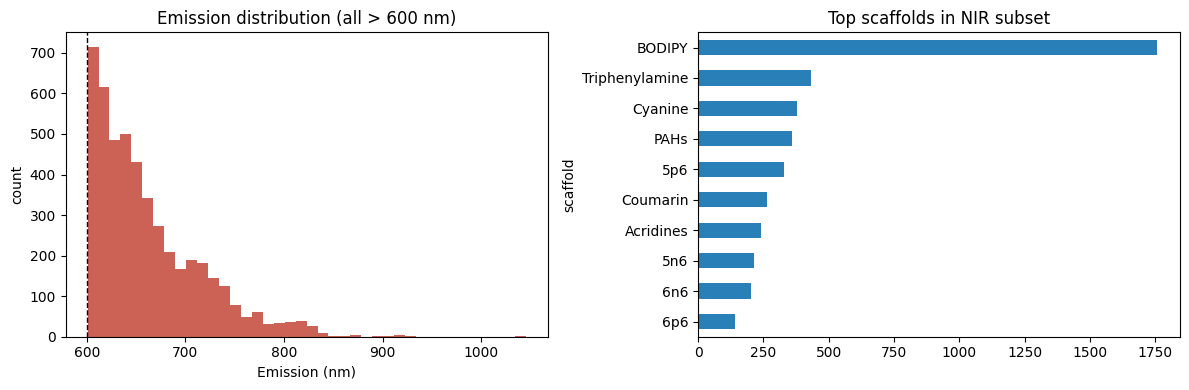

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(nir["emission_nm"].dropna(), bins=40, color="#c0392b", alpha=0.8)
ax[0].axvline(600, color="k", ls="--", lw=1)
ax[0].set_xlabel("Emission (nm)"); ax[0].set_ylabel("count")
ax[0].set_title("Emission distribution (all > 600 nm)")

nir["scaffold"].value_counts().head(10).plot.barh(ax=ax[1], color="#2980b9")
ax[1].invert_yaxis(); ax[1].set_title("Top scaffolds in NIR subset")
plt.tight_layout(); plt.show()

In [6]:
# Why absorption is "easier" than emission: compare their spread
print("absorption std:", round(nir['absorption_nm'].std(),1), "nm")
print("emission   std:", round(nir['emission_nm'].std(),1), "nm")
both = nir.dropna(subset=['absorption_nm','emission_nm'])
print("Stokes shift std:", round((both['emission_nm']-both['absorption_nm']).std(),1), "nm")

absorption std: 92.0 nm
emission   std: 53.5 nm
Stokes shift std: 71.5 nm


## 5. Featurize molecules

Each molecule → Morgan (ECFP) fingerprint + RDKit descriptors;
solvent → its own fingerprint. (Defined in `src/featurize.py`.)

In [7]:
from featurize import featurize_pair, feature_length
print("Feature vector length:", feature_length())
v = featurize_pair(nir['smiles'].iloc[0], nir['solvent'].iloc[0])
print("Example vector shape:", v.shape)

Feature vector length: 1164
Example vector shape: (1164,)


## 6. Train the 4 prediction models

One gradient-boosted-tree model per property. (This runs `src/train_model.py`.)

In [8]:
!python src/train_model.py

Backend: LightGBM
Loading /home/claude/nir-fluorophore/data/nir_dataset.csv
Featurizing molecules (this takes ~10-30s)...


  feature matrix: (4766, 1164)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   absorption_nm: MAE=14.258 nm  R2=0.917  (train=3749, test=938)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


            plqy: MAE=0.102   R2=0.725  (train=2862, test=716)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


         epsilon: MAE=0.143 log10(M-1cm-1)  R2=0.801  (train=1505, test=377)



Saved 4 models + metrics.json into /home/claude/nir-fluorophore/models


## 7. Evaluate — metrics + parity plots

In [9]:
with open("models/metrics.json") as f:
    metrics = json.load(f)
rows = [{"property":k, "MAE":v["MAE"], "R2":v["R2"], "unit":v["unit"],
         "n_test":v["n_test"]} for k,v in metrics["targets"].items()]
pd.DataFrame(rows)

,property,MAE,R2,unit,n_test
0,absorption_nm,14.2579,0.9172,nm,938
1,emission_nm,14.9924,0.7880,nm,954
2,plqy,0.1025,0.7252,,716
3,epsilon,0.1431,0.8011,log10(M-1cm-1),377


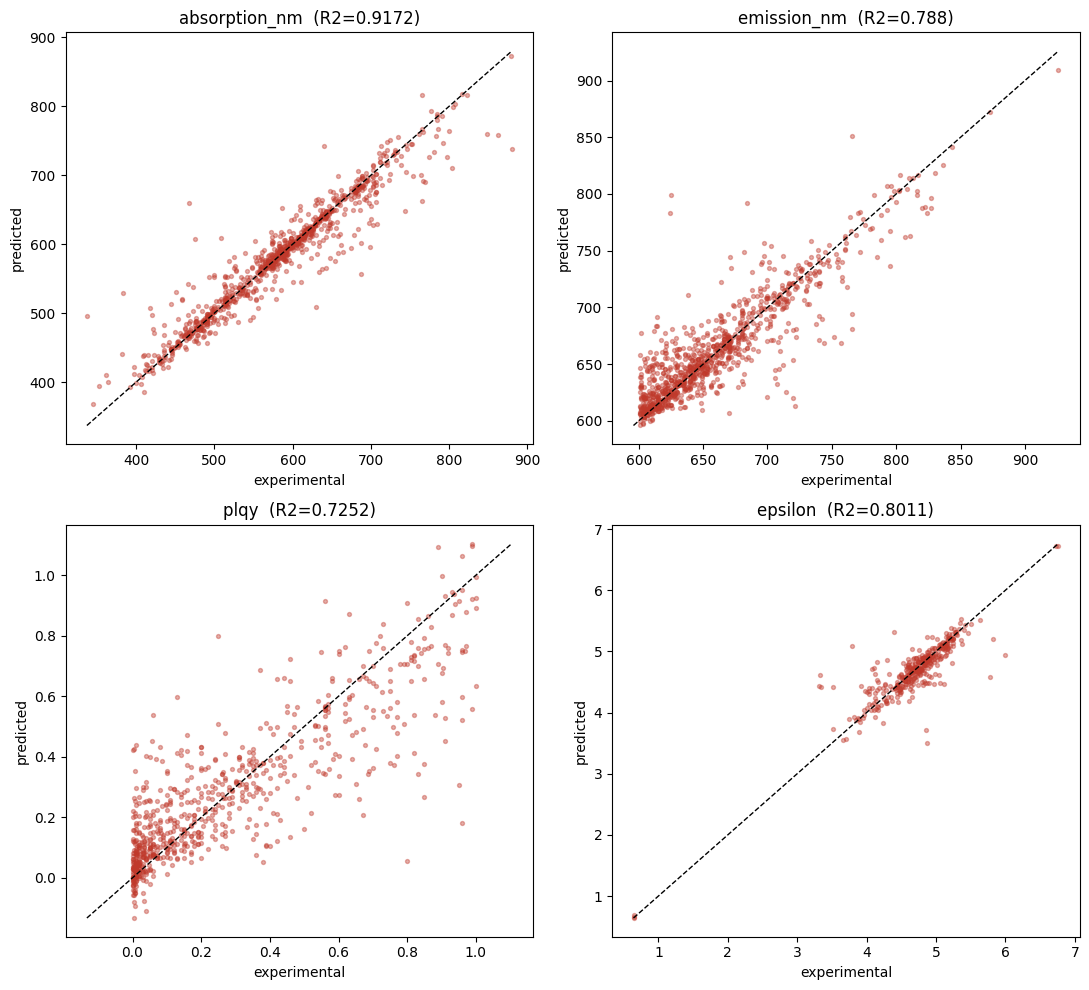

In [10]:
# Parity plots (predicted vs experimental) on a held-out split
import joblib
from sklearn.model_selection import train_test_split

# rebuild features once
feats, mask = [], []
for smi, solv in zip(nir["smiles"], nir["solvent"]):
    fv = featurize_pair(smi, solv)
    mask.append(fv is not None)
    if fv is not None: feats.append(fv)
X_all = np.array(feats, dtype=np.float32)
d = nir[mask].reset_index(drop=True)

targets = [("absorption_nm",False),("emission_nm",False),
           ("plqy",False),("epsilon",True)]
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax,(col,use_log) in zip(axes.ravel(), targets):
    sub = d[d[col].notna()]; idx = sub.index.values
    y = sub[col].values.astype(float)
    yt = np.log10(np.clip(y,1,None)) if use_log else y
    Xtr,Xte,ytr,yte = train_test_split(X_all[idx], yt, test_size=0.2, random_state=42)
    bundle = joblib.load(f"models/model_{col}.pkl")
    pred = bundle["model"].predict(Xte)
    ax.scatter(yte, pred, s=8, alpha=0.4, color="#c0392b")
    lo,hi = min(yte.min(),pred.min()), max(yte.max(),pred.max())
    ax.plot([lo,hi],[lo,hi],"k--",lw=1)
    r2 = metrics["targets"][col]["R2"]
    ax.set_title(f"{col}  (R2={r2})"); ax.set_xlabel("experimental"); ax.set_ylabel("predicted")
plt.tight_layout(); plt.show()

## 8. Generate new NIR fluorophore candidates

Mutate real NIR molecules with wavelength-tuning substituents, keep
valid/novel/drug-like ones, and rank by an objective.

In [11]:
from generate import generate
cands = generate(n_candidates=15, objective="max_emission", solvent="O")
cands[["smiles","absorption_nm","emission_nm","plqy","epsilon","brightness"]].head(15)

,smiles,absorption_nm,emission_nm,plqy,epsilon,brightness
0,CC(C)[Si](C#Cc1c2nc3ccccc3nc2c(C#C[Si](C(C)C)(...,664.7,760.1,0.142,29004.0,4111.0
1,C[N+]1=C(C=CC2=C3Oc4c(cc5c6c4CCCN6CCC5)C(c4ccc...,758.8,759.2,0.200,81526.0,16296.0
2,CC1=[N+]2C(=C(NC(C)c3ccccc3)c3cc(-c4cc5n(c4)[B...,578.2,674.2,0.000,49748.0,0.0
3,CN1C(=CC2=C([O-])C(=CC3=[N+](C)c4ccccc4C3(C)C)...,616.1,665.0,0.025,50893.0,1250.0
4,CCc1cc(C=C(c2ccccc2)c2ccccc2)ccc1N1c2c(cc(/C=C...,521.8,660.5,0.064,29555.0,1894.0
5,O=[N+]([O-])c1ccc(-c2sc(N(c3ccccc3)c3ccccc3)nc...,518.7,654.5,0.131,21958.0,2882.0
6,CCCCCCCCCOC1Cc2cc(/C=N/N(c3ccccc3)c3ccc(C=C4SC...,499.8,646.8,0.096,24633.0,2376.0
7,CCOC(=O)CN1C(=O)C2=C(c3ccc(N4CCCCC4)cc3C#N)N(C...,574.1,643.7,0.034,42966.0,1472.0
8,CCc1c(C)c2n(c1C)[B-](F)(F)[N+]1=C(C=C3c4ccccc4...,585.8,637.6,0.274,29903.0,8194.0
9,N#CC(C#N)=C(/C=C/c1ccc(N(c2ccccc2)c2cccc(Cl)c2...,529.0,636.6,0.099,31128.0,3068.0


Top candidate emission: 760.1 nm


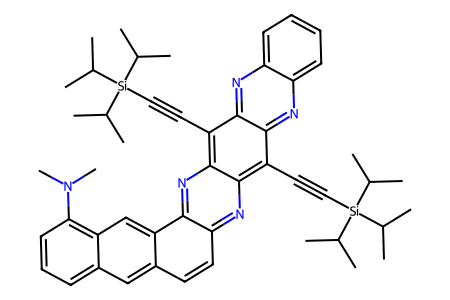

In [12]:
# Draw the top candidate
from rdkit import Chem
from rdkit.Chem import Draw
top = cands.iloc[0]
print("Top candidate emission:", top["emission_nm"], "nm")
Draw.MolToImage(Chem.MolFromSmiles(top["smiles"]), size=(450,300))

## 9. Predict properties of any molecule

In [13]:
from generate import predict_properties
smiles = "CCN(CC)c1ccc2c(c1)oc1cc(=[N+](CC)CC)ccc1c2-c1ccccc1C(=O)O"  # Rhodamine B
props = predict_properties(smiles, "O")  # in water
for k,v in props.items():
    print(f"{k:>14}: {v:,.2f}")

 absorption_nm: 581.04
   emission_nm: 639.90
          plqy: 0.14
       epsilon: 32,010.33


## Done ✅

- Filtered NIR dataset → `data/nir_dataset.csv`
- Trained models → `models/`
- Launch the web app with: `streamlit run app.py`
- Deploy by pushing to GitHub → share.streamlit.io